In [ ]:
import zipfile
import os

def unzip_and_prepare(zip_file_path, extract_to='.'):
    """
    Unzips a file and returns a list of extracted file paths.

    :param zip_file_path: The path to the zip file.
    :param extract_to: The directory where the files will be extracted.
    :return: A list of paths to the extracted files.
    """
    extracted_files = []

    # Check if the zip file exists
    if not os.path.exists(zip_file_path):
        raise FileNotFoundError(f"The zip file {zip_file_path} does not exist.")

    # Unzip the file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
        extracted_files = zip_ref.namelist()

    # Return the list of extracted file paths
    extracted_file_paths = [os.path.join(extract_to, file) for file in extracted_files]

    return extracted_file_paths

# Example of reading CSV data from the extracted files
import pandas as pd

def load_csv(file_path):
    """
    Loads a CSV file into a pandas DataFrame.

    :param file_path: The path to the CSV file.
    :return: A pandas DataFrame containing the CSV data.
    """
    return pd.read_csv(file_path)


# Example usage
if __name__ == "__main__":
    zip_file = 'nlp-getting-started.zip'  # Specify the zip file path
    extract_dir = './extracted_data'  # Specify where to extract the files

    # Unzip and get list of extracted files
    extracted_files = unzip_and_prepare(zip_file, extract_dir)
    print("Extracted files:", extracted_files)

    # Load data (assuming one of the extracted files is a CSV)
    for file in extracted_files:
        if file.endswith('.csv'):
            df = load_csv(file)
            print(f"Data from {file}:")
            print(df.head())


Extracted files: ['./extracted_data/sample_submission.csv', './extracted_data/test.csv', './extracted_data/train.csv']
Data from ./extracted_data/sample_submission.csv:
   id  target
0   0       0
1   2       0
2   3       0
3   9       0
4  11       0
Data from ./extracted_data/test.csv:
   id keyword location                                               text
0   0     NaN      NaN                 Just happened a terrible car crash
1   2     NaN      NaN  Heard about #earthquake is different cities, s...
2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
3   9     NaN      NaN           Apocalypse lighting. #Spokane #wildfires
4  11     NaN      NaN      Typhoon Soudelor kills 28 in China and Taiwan
Data from ./extracted_data/train.csv:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada 

In [ ]:
test_data = load_csv(extracted_files[1])
train_data = load_csv(extracted_files[2])[['text', 'target']]

In [ ]:
# Analyze the training data
print("Training data info:")
print(train_data.info())
print("\nTraining data description:")
print(train_data.describe())
print("\nTraining data shape:", train_data.shape)
print("\nTraining data column names:", train_data.columns)
print("\nNumber of missing values per column:\n", train_data.isnull().sum())
print("\nValue counts for target variable 'target':\n", train_data['target'].value_counts())

# You can add more specific analysis based on your needs, for example:
# - Explore the distribution of text lengths
# - Analyze the frequency of words in the text
# - Identify potential outliers or anomalies
# - Check for class imbalance in the target variable
# - Visualize the data using histograms, scatter plots, etc.

# Example: Analyze text length
# train_data['text_length'] = train_data['text'].apply(len)
# print("\nDistribution of text lengths:\n", train_data['text_length'].describe())

# Example: Analyze word frequency
# from collections import Counter
# all_words = ' '.join(train_data['text']).split()
# word_counts = Counter(all_words)
# print("\nMost common words:\n", word_counts.most_common(10))


Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7613 non-null   object
 1   target  7613 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 119.1+ KB
None

Training data description:
           target
count  7613.00000
mean      0.42966
std       0.49506
min       0.00000
25%       0.00000
50%       0.00000
75%       1.00000
max       1.00000

Training data shape: (7613, 2)

Training data column names: Index(['text', 'target'], dtype='object')

Number of missing values per column:
 text      0
target    0
dtype: int64

Value counts for target variable 'target':
 target
0    4342
1    3271
Name: count, dtype: int64


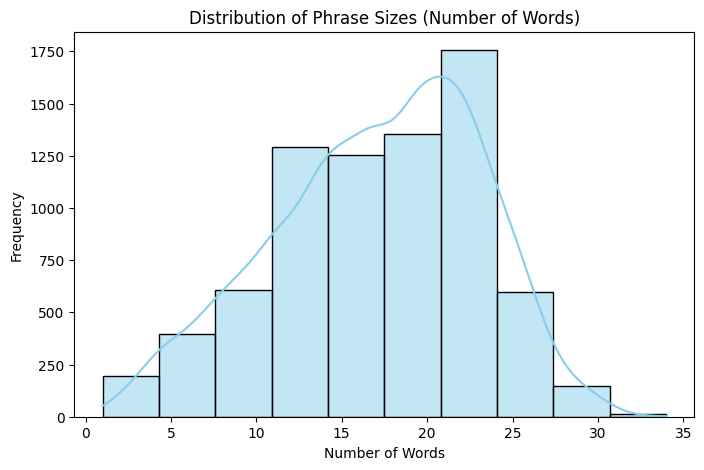

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Function to count words in each phrase
def count_words(phrase):
    # Use regex to split by spaces and remove punctuation
    words = re.findall(r'\b\w+\b', phrase)
    return len(words)

# Assume df is already defined with a 'text' column
df['phrase_size'] = df['text'].apply(count_words)

# Step 4: Plotting the distribution of phrase sizes
plt.figure(figsize=(8, 5))
sns.histplot(df['phrase_size'], bins=10, kde=True, color='skyblue')

# Adding labels and title
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Phrase Sizes (Number of Words)')

plt.show()


In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
# curate the sentences
!pip install nltk
!pip install spacy
!pip install gensim
!python -m spacy download en_core_web_sm
!pip install transformers

!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.parsing.preprocessing import remove_stopwords
from transformers import RobertaTokenizerFast
import spacy
import string
nlp = spacy.load('en_core_web_sm')
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
unzip:  cannot find or open /usr/share/nltk_data/corpora/wordnet.zip, /usr/share/nltk_data/corpora/wordnet.zip.zip or /usr/share/nltk_data/corpora/wordnet.zip.ZIP.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
roberta = RobertaTokenizerFast.from_pretrained('cardiffnlp/twitter-roberta-base-emotion')

maximum_tensor_length = 100

def encode(sentence):
  print(sentence)
  embeddings = roberta(sentence)
  return embeddings

def retrieve_input_ids(embedding):
  input_ids = embedding['input_ids'][:maximum_tensor_length]
  base = np.zeros(maximum_tensor_length)
  base[:len(input_ids)] = input_ids
  return base

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# set of stop words
stop_words = spacy.lang.en.stop_words.STOP_WORDS
lemmatizer = WordNetLemmatizer()
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

def remove_stop_words(sentence):
  doc = nlp(sentence)
  filtered_tokens = [token for token in doc if not token.is_stop]
  return ' '.join([token.text for token in filtered_tokens])


def preprocess_text(text):
    text=str(text).lower() #Converts text to lowercase
    text=re.sub('\[.*?\]', '', text) #removes HTML tags
    text=re.sub('https?://\S+|www\.\S+', '', text) #removes url
    text=re.sub('[%s]' % re.escape(string.punctuation),'',text) #removes punctuations
    tokens = nltk.word_tokenize(text) # Tokenize the text
    words = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stop words and lemmatize the words
    return ' '.join(words) # Join the words back into a string

train_data['processed_text'] = train_data['text'].apply(preprocess_text).apply(encode).apply(retrieve_input_ids)
print(train_data['processed_text'])

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
kingdom divided headed destruction city house divided stand matthew 1232
megadethsymphony destruction
american war planner singled hiroshima destruction
thingsihate watching care head total destruction able
hassanrouhani war doomed destruction loss money invest iran inside outside
crackdown 3 destruction restricted multiplayer crackdown 3 impressed earlier week demonstratio
blossominglilac destruction ruined
arrogant destruction think earth need doesnt
megadeth week symphony destruction
crackdown 3 destruction restricted multiplayer crackdown 3 impressed earlier week demonstratio
whats happening destruction
day 1998 appetite destruction go 1 billboard album chart stay 57 week
alexeivolkov1 mcfaul equal spirit leave roskomnadzor ridiculously politicized destruction illegal food
thats ultimate road destruction
self destruction mode
bonn1egreer angel history propelled future wind progress leaf wake pile death destruction wb
marquei como v

In [ ]:
tr_data = train_data['processed_text'].to_numpy()
tr_label = train_data['target'].to_numpy()

assert tr_data.shape == tr_label.shape

In [ ]:
!pip install datasets transformers huggingface_hub
!apt-get install git-lfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 11.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)

# Tokenize the datasets
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

train_data = tr_data.map(preprocess_function, batched=True)
test_data = t_data.map(preprocess_function, batched=True)

# Set the format for PyTorch
train_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=data_collator,
)

# Train and evaluate the model
trainer.train()
trainer.evaluate()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'numpy.ndarray' object has no attribute 'map'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1):
        super(Model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.rnn(embedded)
        hidden = hidden[-1, :, :]
        output = self.fc(hidden)
        return output

batch_size = 32
vocab_size = 100000
embedding_dim = 128
hidden_dim = 256
output_dim = 2

model = Model(vocab_size, embedding_dim, hidden_dim, output_dim)

nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TextLabelDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = torch.tensor(self.texts[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return text, label


In [ ]:
array = torch.tensor(np.random.randint(0, vocab_size, size=(32, 100)))
outputs = model(array)

In [ ]:
num_epochs = 50
dataset = TextLabelDataset(tr_data, tr_label)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for texts, labels in dataloader:

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader)}')
